In [ ]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import squidpy as sq
import pandas as pd
import cell2location
import anndata as AnnData
from matplotlib import rcParams
import json
import os
import re
from pathlib import Path
from typing import Any
from squidpy._constants._pkg_constants import Key
from squidpy.datasets._utils import PathLike
from squidpy.read._utils import _load_image, _read_counts
results_folder = '/bigdata/zlin/PanCancer_ICI/data/GSE206245/cell2loc_results'
# create paths and names to results folders for reference regression and cell2location models
ref_run_name = f'{results_folder}/reference_signatures'

In [ ]:
import os
os.listdir('/bigdata/zlin/PanCancer_ICI/data/GSE238364_RAW')

In [5]:
os.listdir('/bigdata/zlin/PanCancer_ICI/data/GSE238264_RAW')

['HCC7NR', 'HCC6NR', 'HCC4R', 'HCC3R', 'HCC2R', 'HCC5NR', '.DS_Store', 'HCC1R']

In [ ]:
def visium(
    path: PathLike,
    sample: str | None = None,
    library_id: str | None = None,
    load_images: bool = True,
    source_image_path: PathLike | None = None,
    **kwargs: Any,
) -> AnnData:
    path = Path(path)
    adata= sc.read_10x_mtx(path=f'{path}/filtered_feature_bc_matrix/')
    Key.uns.spatial = "spatial"
    adata.uns[Key.uns.spatial] = {library_id: {}}
    adata.uns[Key.uns.spatial][library_id][Key.uns.image_key] = {
        res: _load_image(path / f"{Key.uns.spatial}/tissue_{res}_image.png") for res in ["hires", "lowres"]
    }
    adata.uns[Key.uns.spatial][library_id]["scalefactors"] = json.loads(
        (path / f"{Key.uns.spatial}/scalefactors_json.json").read_bytes()
    )
    tissue_positions_file = (
        path / "spatial/tissue_positions.csv"
        if (path / "spatial/tissue_positions.csv").exists()
        else path / "spatial/tissue_positions_list.csv"
    )
    coords = pd.read_csv(
        tissue_positions_file,
        header=1 if tissue_positions_file.name == "tissue_positions.csv" else None,
        index_col=0,
    )
    coords.columns = ["in_tissue", "array_row", "array_col", "pxl_col_in_fullres", "pxl_row_in_fullres"]
    coords.set_index(coords.index.astype(adata.obs.index.dtype), inplace=True)

    adata.obs = pd.merge(adata.obs, coords, how="left", left_index=True, right_index=True)
    adata.obsm[Key.obsm.spatial] = adata.obs[["pxl_row_in_fullres", "pxl_col_in_fullres"]].values
    adata.obs.drop(columns=["pxl_row_in_fullres", "pxl_col_in_fullres"], inplace=True)

    if source_image_path is not None:
        source_image_path = Path(source_image_path).absolute()
        if not source_image_path.exists():
            logg.warning(f"Path to the high-resolution tissue image `{source_image_path}` does not exist")
        adata.uns["spatial"][library_id]["metadata"]["source_image_path"] = str(source_image_path)

    return adata
# load data
print('Loading data')
samples = ['HCC7NR', 'HCC6NR', 'HCC4R', 'HCC3R', 'HCC2R', 'HCC5NR', 'HCC1R']
dict_adata_vis = {
    sample: visium(path=f'/bigdata/zlin/PanCancer_ICI/data/GSE238264_RAW/{sample}', library_id=sample)
    for sample in samples
}

Loading data


FileNotFoundError: Did not find file /bigdata/zlin/PanCancer_ICI/data/GSE238264_RAW/.DS_Store/filtered_feature_bc_matrix/matrix.mtx.gz.

In [4]:
for sample, adata_vis in dict_adata_vis.items():
    print(sample)
    run_name = f'{results_folder}/cell2location_map/{sample}'
    adata_vis.var_names_make_unique()
    # QC
    from scipy.sparse import csr_matrix
    adata_vis.X = adata_vis.X.toarray()
    sc.pp.calculate_qc_metrics(adata_vis, inplace=True)
    adata_vis.X = csr_matrix(adata_vis.X)
    adata_vis.var['mt'] = [gene.startswith('mt-') for gene in adata_vis.var_names]
    adata_vis.obs['mt_frac'] = adata_vis[:, adata_vis.var['mt'].tolist()].X.sum(1).A.squeeze()/adata_vis.obs['total_counts']
    # add sample name to obs names
    adata_vis.obs["sample"] = sample
    adata_vis.obs_names = adata_vis.obs["sample"] + '_' + adata_vis.obs_names
    adata_vis.obs.index.name = 'spot_id'
    # mitochondria-encoded (MT) genes should be removed for spatial mapping
    adata_vis.obsm['mt'] = adata_vis[:, adata_vis.var['mt'].values].X.toarray()
    adata_vis = adata_vis[:, ~adata_vis.var['mt'].values]
    sc.pp.calculate_qc_metrics(adata_vis, inplace=True)
    sc.pp.filter_cells(adata_vis, min_counts=200)

ST10


/bigdata/zlin/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/scanpy/preprocessing/_qc.py:144: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics


ST11


/bigdata/zlin/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/scanpy/preprocessing/_qc.py:144: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics


ST12


...

/bigdata/zlin/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/scanpy/preprocessing/_qc.py:144: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics


ST8


/bigdata/zlin/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/scanpy/preprocessing/_qc.py:144: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics


ST9


/bigdata/zlin/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/scanpy/preprocessing/_qc.py:144: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics


In [ ]:
dict_adata_vis['ST10']

In [1]:
import scanpy as sc
import anndata as an
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [ ]:
adata_spatial_anterior = sc.datasets.visium_sge(
    sample_id="V1_Mouse_Brain_Sagittal_Anterior"
)
adata_spatial_posterior = sc.datasets.visium_sge(
    sample_id="V1_Mouse_Brain_Sagittal_Posterior"
)


/tmp/ipykernel_3083307/562932817.py:1: FutureWarning: Use `squidpy.datasets.visium` instead.
  adata_spatial_anterior = sc.datasets.visium_sge(
/bigdata/zlin/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/scanpy/datasets/_datasets.py:558: FutureWarning: Use `squidpy.read.visium` instead.
  return read_visium(sample_dir, source_image_path=source_image_path)
/bigdata/zlin/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/bigdata/zlin/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/tmp/ipykernel_3083307/562932817.py:4: FutureWarning: Use `squidpy.datasets.visium` instead.
  adata_spatial_posterior = sc.datasets.visium_sge(
/bigdata/zlin

In [3]:
adata_spatial_anterior.var_names_make_unique()
adata_spatial_posterior.var_names_make_unique()
sc.pp.calculate_qc_metrics(adata_spatial_anterior, inplace=True)
sc.pp.calculate_qc_metrics(adata_spatial_posterior, inplace=True)

In [5]:
for adata in [
    adata_spatial_anterior,
    adata_spatial_posterior,
]:
    adata.layers['counts'] = adata.X.copy()
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000, inplace=True)

/tmp/ipykernel_3083307/157023373.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_spatial_anterior,img_key="lowres", color=["total_counts", "n_genes_by_counts"])


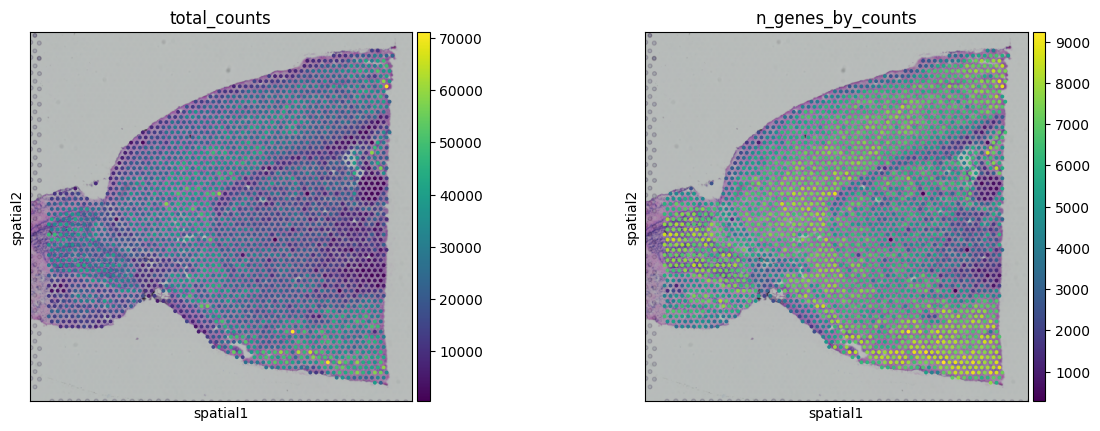

In [8]:
sc.pl.spatial(adata_spatial_anterior,img_key="lowres", color=["total_counts", "n_genes_by_counts"])

/tmp/ipykernel_3083307/4222081900.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_spatial_posterior,img_key="lowres", color=["total_counts", "n_genes_by_counts"])


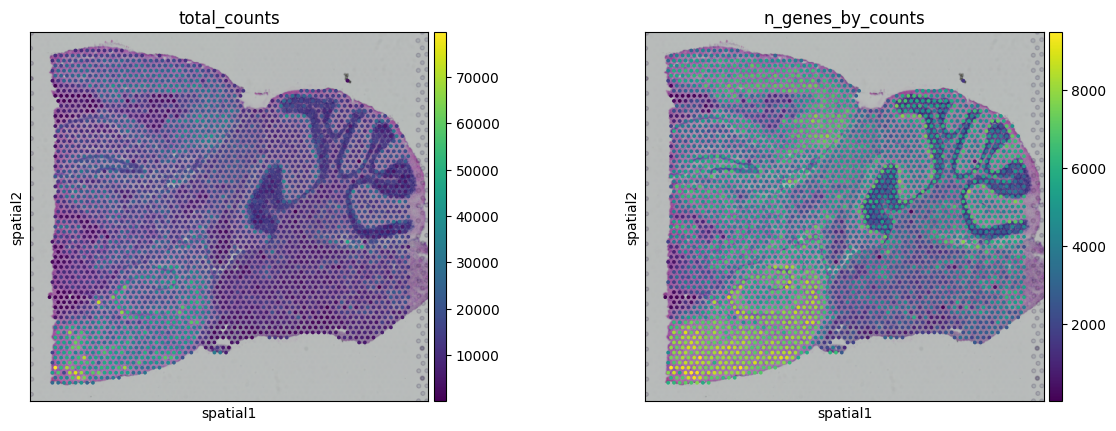

In [9]:
sc.pl.spatial(adata_spatial_posterior,img_key="lowres", color=["total_counts", "n_genes_by_counts"])

In [11]:
adata_spatial = sc.concat(
    [adata_spatial_anterior, adata_spatial_posterior],
    label="library_id",
    uns_merge="unique",
    keys=[
        k
        for d in [
            [adata_spatial_anterior, adata_spatial_posterior][0].uns["spatial"],
            [adata_spatial_anterior, adata_spatial_posterior][1].uns["spatial"],
        ]
        for k, v in d.items()
    ],
    index_unique="-",
)

In [10]:
adata_spatial_anterior

AnnData object with n_obs × n_vars = 2695 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'spatial', 'log1p', 'hvg'
    obsm: 'spatial'
    layers: 'counts'

In [12]:
adata_spatial

AnnData object with n_obs × n_vars = 6050 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'library_id'
    uns: 'spatial', 'log1p', 'hvg'
    obsm: 'spatial'
    layers: 'counts'

In [ ]:
adata_spatial.uns['spatial'].keys()

dict_keys(['V1_Mouse_Brain_Sagittal_Anterior', 'V1_Mouse_Brain_Sagittal_Posterior'])

/tmp/ipykernel_3083307/1439749948.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_3083307/1439749948.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


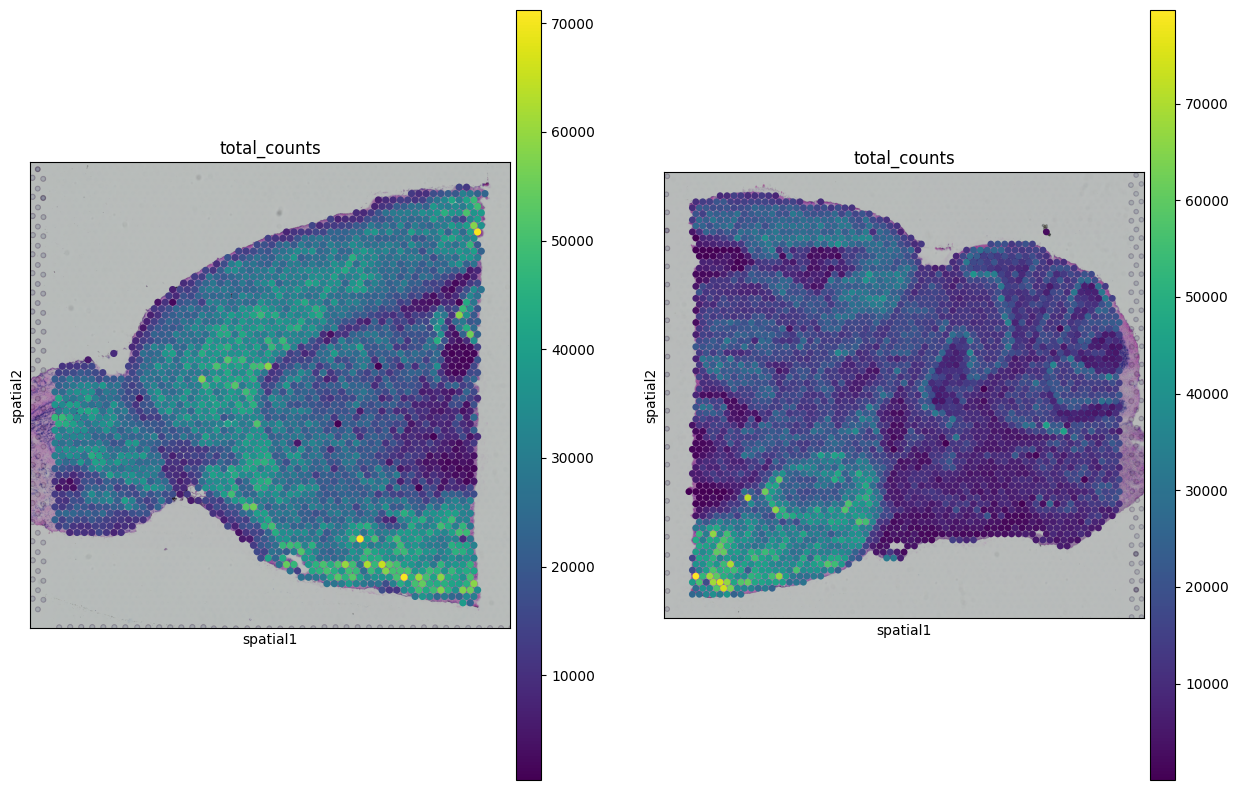

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(15, 10))
for i, library in enumerate(
    ["V1_Mouse_Brain_Sagittal_Anterior", "V1_Mouse_Brain_Sagittal_Posterior"]
):
    ad = adata_spatial[adata_spatial.obs.library_id == library, :].copy()
    sc.pl.spatial(
        ad,
        img_key="hires",
        library_id=library,
        color="total_counts",
        size=1.5,
        legend_loc=None,
        show=False,
        ax=axs[i],
    )
